# Modeling
**Proyek:** Analisis Sentimen Ulasan Shopee — Bummi Tani  
**Tujuan:** Melatih 3 model klasifikasi (SVM, Naïve Bayes, KNN) menggunakan data latih yang sudah di-SMOTE, dengan validasi K-Fold Cross Validation (k=10).

---

## Import Library

In [2]:
import numpy as np
import pandas as pd
import os
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# Model-model
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

# Validasi
from sklearn.model_selection import cross_val_score, StratifiedKFold

## Load Artefak dari Data Preparation

In [3]:
# Path ke folder Data Preparation
PREP_DIR = '../3-Data-Preparation'
OUTPUT_DIR = '.'  # Simpan model di folder ini

def load_artifact(filename, base_dir=PREP_DIR):
    path = os.path.join(base_dir, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f'File tidak ditemukan: {path}')
    obj = joblib.load(path)
    print(f' Dimuat: {path}')
    return obj

print('Memuat artefak')
X_train_smote = load_artifact('X_train_smote.pkl')
y_train_smote = load_artifact('y_train_smote.pkl')
X_test         = load_artifact('X_test.pkl')
y_test         = load_artifact('y_test.pkl')

print(f'\n Semua artefak berhasil dimuat.')
print(f'   → X_train_smote : {X_train_smote.shape}')
print(f'   → y_train_smote : {y_train_smote.shape} | Positif={y_train_smote.sum()}, Negatif={(y_train_smote==0).sum()}')
print(f'   → X_test        : {X_test.shape}')
print(f'   → y_test        : {y_test.shape}  | Positif={y_test.sum()}, Negatif={(y_test==0).sum()}')

Memuat artefak
 Dimuat: ../3-Data-Preparation/X_train_smote.pkl
 Dimuat: ../3-Data-Preparation/y_train_smote.pkl
 Dimuat: ../3-Data-Preparation/X_test.pkl
 Dimuat: ../3-Data-Preparation/y_test.pkl

 Semua artefak berhasil dimuat.
   → X_train_smote : (678, 801)
   → y_train_smote : (678,) | Positif=339, Negatif=339
   → X_test        : (97, 801)
   → y_test        : (97,)  | Positif=85, Negatif=12


## Konfigurasi K-Fold Cross Validation

In [4]:
K_FOLDS = 10
RANDOM_STATE = 42

kfold = StratifiedKFold(
    n_splits=K_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(f'K-Fold Cross Validation dikonfigurasi:')
print(f'   → k = {K_FOLDS} fold')
print(f'   → Stratified = True (menjaga proporsi kelas di setiap fold)')
print(f'   → Random State = {RANDOM_STATE}')

K-Fold Cross Validation dikonfigurasi:
   → k = 10 fold
   → Stratified = True (menjaga proporsi kelas di setiap fold)
   → Random State = 42


## Model 1: SVM dengan Kernel Linear

In [5]:
print('='*55)
print('  MODEL 1: Support Vector Machine (Kernel Linear)')
print('='*55)

# Inisialisasi model
# LinearSVC lebih efisien untuk TF-IDF sparse matrix
svm_model = LinearSVC(
    C=1.0,
    max_iter=2000,
    random_state=RANDOM_STATE
)

# K-Fold Cross Validation
print(f'\n Menjalankan {K_FOLDS}-Fold Cross Validation pada SVM')
start = time.time()
svm_cv_scores = cross_val_score(
    svm_model, X_train_smote, y_train_smote,
    cv=kfold, scoring='accuracy', n_jobs=-1
)
svm_cv_time = time.time() - start

print(f'\n Hasil Cross Validation SVM:')
for i, score in enumerate(svm_cv_scores, 1):
    print(f'   Fold {i:2d}: {score:.4f} ({score*100:.2f}%)')
print(f'   ─────────────────────────────')
print(f'   Rata-rata Akurasi : {svm_cv_scores.mean():.4f} ({svm_cv_scores.mean()*100:.2f}%)')
print(f'   Standar Deviasi   : {svm_cv_scores.std():.4f}')
print(f'   Waktu CV          : {svm_cv_time:.2f} detik')

# Latih model pada seluruh data latih
print(f'\n Melatih SVM pada seluruh data latih SMOTE...')
svm_model.fit(X_train_smote, y_train_smote)
print(f' SVM berhasil dilatih!')

  MODEL 1: Support Vector Machine (Kernel Linear)

 Menjalankan 10-Fold Cross Validation pada SVM

 Hasil Cross Validation SVM:
   Fold  1: 0.9706 (97.06%)
   Fold  2: 0.9559 (95.59%)
   Fold  3: 0.9559 (95.59%)
   Fold  4: 0.9559 (95.59%)
   Fold  5: 1.0000 (100.00%)
   Fold  6: 0.9706 (97.06%)
   Fold  7: 0.8971 (89.71%)
   Fold  8: 0.9706 (97.06%)
   Fold  9: 0.9701 (97.01%)
   Fold 10: 0.9403 (94.03%)
   ─────────────────────────────
   Rata-rata Akurasi : 0.9587 (95.87%)
   Standar Deviasi   : 0.0253
   Waktu CV          : 5.35 detik

 Melatih SVM pada seluruh data latih SMOTE...
 SVM berhasil dilatih!


## Model 2: Multinomial Naïve Bayes

In [6]:
print('='*55)
print('  MODEL 2: Multinomial Naïve Bayes')
print('='*55)

import scipy.sparse as sp

# MultinomialNB memerlukan nilai non-negatif
# Pastikan matrix TF-IDF tidak ada nilai negatif (seharusnya tidak)
nb_model = MultinomialNB(alpha=1.0)  # alpha: Laplace smoothing

# Pastikan matrix non-negatif untuk MNB
X_train_mnb = X_train_smote.copy()
if sp.issparse(X_train_mnb):
    X_train_mnb.data = np.abs(X_train_mnb.data)

# K-Fold Cross Validation
print(f'\n Menjalankan {K_FOLDS}-Fold Cross Validation pada Naïve Bayes')
start = time.time()
nb_cv_scores = cross_val_score(
    nb_model, X_train_mnb, y_train_smote,
    cv=kfold, scoring='accuracy', n_jobs=-1
)
nb_cv_time = time.time() - start

print(f'\nHasil Cross Validation Naïve Bayes:')
for i, score in enumerate(nb_cv_scores, 1):
    print(f'   Fold {i:2d}: {score:.4f} ({score*100:.2f}%)')
print(f'   ─────────────────────────────')
print(f'   Rata-rata Akurasi : {nb_cv_scores.mean():.4f} ({nb_cv_scores.mean()*100:.2f}%)')
print(f'   Standar Deviasi   : {nb_cv_scores.std():.4f}')
print(f'   Waktu CV          : {nb_cv_time:.2f} detik')

# Latih model pada seluruh data latih
print(f'\n Melatih Naïve Bayes pada seluruh data latih SMOTE')
nb_model.fit(X_train_mnb, y_train_smote)
print(f' Naïve Bayes berhasil dilatih!')

  MODEL 2: Multinomial Naïve Bayes

 Menjalankan 10-Fold Cross Validation pada Naïve Bayes

Hasil Cross Validation Naïve Bayes:
   Fold  1: 0.9412 (94.12%)
   Fold  2: 0.9265 (92.65%)
   Fold  3: 0.8971 (89.71%)
   Fold  4: 0.8971 (89.71%)
   Fold  5: 0.8824 (88.24%)
   Fold  6: 0.9412 (94.12%)
   Fold  7: 0.8676 (86.76%)
   Fold  8: 0.9412 (94.12%)
   Fold  9: 0.8806 (88.06%)
   Fold 10: 0.8955 (89.55%)
   ─────────────────────────────
   Rata-rata Akurasi : 0.9070 (90.70%)
   Standar Deviasi   : 0.0266
   Waktu CV          : 0.13 detik

 Melatih Naïve Bayes pada seluruh data latih SMOTE
 Naïve Bayes berhasil dilatih!


## Model 3: K-Nearest Neighbor (KNN)

In [7]:
print('='*55)
print('  MODEL 3: K-Nearest Neighbor (KNN)')
print('='*55)

# Pilih k optimal (default k=5, bisa disesuaikan)
# Gunakan nilai ganjil untuk menghindari tie
K_NEIGHBORS = 5

knn_model = KNeighborsClassifier(
    n_neighbors=K_NEIGHBORS,
    metric='cosine',      # Cocok untuk teks/TF-IDF
    algorithm='brute',    # Diperlukan untuk cosine distance
    n_jobs=-1
)

# K-Fold Cross Validation
print(f'\n Menjalankan {K_FOLDS}-Fold Cross Validation pada KNN (k={K_NEIGHBORS})...')
print('   (KNN lebih lambat karena berbasis jarak — harap tunggu)')
start = time.time()
knn_cv_scores = cross_val_score(
    knn_model, X_train_smote, y_train_smote,
    cv=kfold, scoring='accuracy', n_jobs=-1
)
knn_cv_time = time.time() - start

print(f'\n Hasil Cross Validation KNN (k={K_NEIGHBORS}):')
for i, score in enumerate(knn_cv_scores, 1):
    print(f'   Fold {i:2d}: {score:.4f} ({score*100:.2f}%)')
print(f'   ─────────────────────────────')
print(f'   Rata-rata Akurasi : {knn_cv_scores.mean():.4f} ({knn_cv_scores.mean()*100:.2f}%)')
print(f'   Standar Deviasi   : {knn_cv_scores.std():.4f}')
print(f'   Waktu CV          : {knn_cv_time:.2f} detik')

# Latih model pada seluruh data latih
print(f'\n Melatih KNN pada seluruh data latih SMOTE')
knn_model.fit(X_train_smote, y_train_smote)
print(f'KNN berhasil dilatih!')

  MODEL 3: K-Nearest Neighbor (KNN)

 Menjalankan 10-Fold Cross Validation pada KNN (k=5)...
   (KNN lebih lambat karena berbasis jarak — harap tunggu)

 Hasil Cross Validation KNN (k=5):
   Fold  1: 0.8676 (86.76%)
   Fold  2: 0.8824 (88.24%)
   Fold  3: 0.8235 (82.35%)
   Fold  4: 0.8971 (89.71%)
   Fold  5: 0.8382 (83.82%)
   Fold  6: 0.9265 (92.65%)
   Fold  7: 0.8824 (88.24%)
   Fold  8: 0.9559 (95.59%)
   Fold  9: 0.9254 (92.54%)
   Fold 10: 0.8507 (85.07%)
   ─────────────────────────────
   Rata-rata Akurasi : 0.8850 (88.50%)
   Standar Deviasi   : 0.0400
   Waktu CV          : 0.32 detik

 Melatih KNN pada seluruh data latih SMOTE
KNN berhasil dilatih!


## Perbandingan Hasil Cross Validation

In [8]:
# Tabel ringkasan
cv_results = pd.DataFrame({
    'Model': ['SVM (Kernel Linear)', 'Multinomial Naïve Bayes', f'KNN (k={K_NEIGHBORS})'],
    'Rata-rata Akurasi CV (%)': [
        svm_cv_scores.mean() * 100,
        nb_cv_scores.mean() * 100,
        knn_cv_scores.mean() * 100
    ],
    'Std Deviasi (%)': [
        svm_cv_scores.std() * 100,
        nb_cv_scores.std() * 100,
        knn_cv_scores.std() * 100
    ],
    'Waktu CV (detik)': [svm_cv_time, nb_cv_time, knn_cv_time]
}).round(4)

cv_results = cv_results.sort_values('Rata-rata Akurasi CV (%)', ascending=False).reset_index(drop=True)

print('='*65)
print('  RINGKASAN PERBANDINGAN 10-FOLD CROSS VALIDATION')
print('='*65)
print(cv_results.to_string(index=False))
print(f'\n Model Terbaik (CV): {cv_results.iloc[0]["Model"]} — {cv_results.iloc[0]["Rata-rata Akurasi CV (%)"]:.2f}%')

  RINGKASAN PERBANDINGAN 10-FOLD CROSS VALIDATION
                  Model  Rata-rata Akurasi CV (%)  Std Deviasi (%)  Waktu CV (detik)
    SVM (Kernel Linear)                   95.8692           2.5343            5.3454
Multinomial Naïve Bayes                   90.7024           2.6582            0.1309
              KNN (k=5)                   88.4965           3.9967            0.3226

 Model Terbaik (CV): SVM (Kernel Linear) — 95.87%


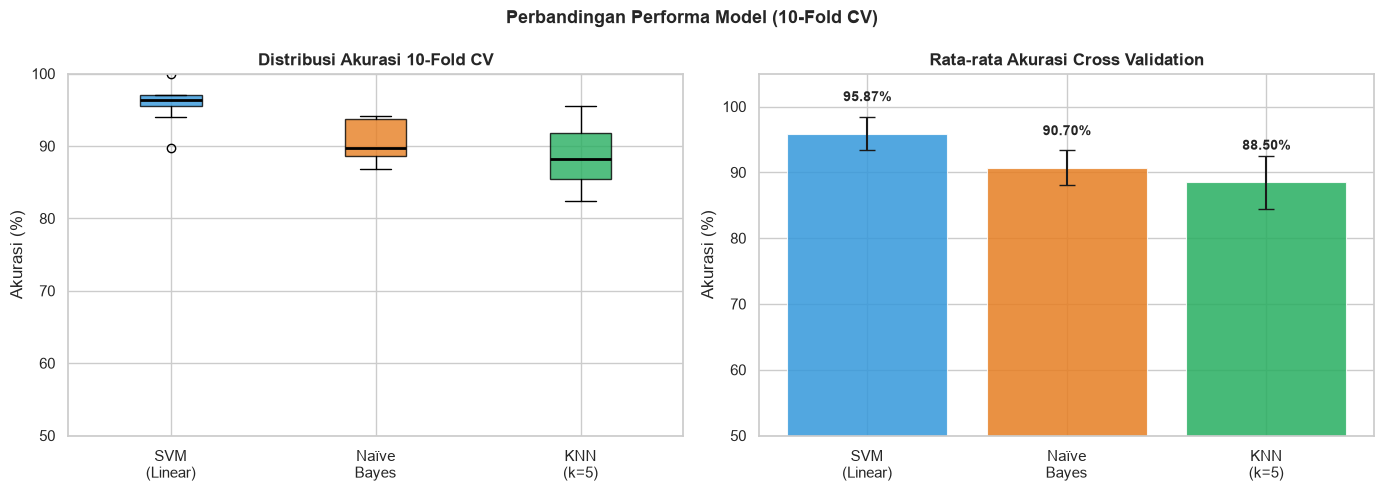

In [9]:
# Visualisasi boxplot perbandingan CV scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
all_scores = [
    svm_cv_scores * 100,
    nb_cv_scores * 100,
    knn_cv_scores * 100
]
model_labels = ['SVM\n(Linear)', 'Naïve\nBayes', f'KNN\n(k={K_NEIGHBORS})']
colors_box = ['#3498DB', '#E67E22', '#27AE60']

bp = axes[0].boxplot(all_scores, tick_labels=model_labels, patch_artist=True,
                      medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_title(f'Distribusi Akurasi {K_FOLDS}-Fold CV', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Akurasi (%)')
axes[0].set_ylim(50, 100)

# Bar chart rata-rata
means = [s.mean() for s in all_scores]   # ← removed * 100 (already in %)
stds  = [s.std()  for s in all_scores]   # ← removed * 100 (already in %)
bars = axes[1].bar(model_labels, means, yerr=stds, color=colors_box, edgecolor='white',
                    capsize=6, alpha=0.85, linewidth=0.8)
for bar, mean in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(stds) + 0.5,
                 f'{mean:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].set_title('Rata-rata Akurasi Cross Validation', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Akurasi (%)')
axes[1].set_ylim(50, 105)

plt.suptitle(f'Perbandingan Performa Model ({K_FOLDS}-Fold CV)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Simpan Model untuk Fase Evaluasi

In [10]:
models = {
    'svm_model.pkl': svm_model,
    'nb_model.pkl': nb_model,
    'knn_model.pkl': knn_model,
}

for filename, model in models.items():
    path = os.path.join(OUTPUT_DIR, filename)
    joblib.dump(model, path)
    print(f'  Model disimpan: {path}')

# Simpan juga hasil CV untuk referensi
cv_results.to_csv(os.path.join(OUTPUT_DIR, 'cv_results.csv'), index=False)
print(f'  Hasil CV disimpan: cv_results.csv')

print(f'\n Semua model berhasil disimpan di folder: {os.path.abspath(OUTPUT_DIR)}')

  Model disimpan: ./svm_model.pkl
  Model disimpan: ./nb_model.pkl
  Model disimpan: ./knn_model.pkl
  Hasil CV disimpan: cv_results.csv

 Semua model berhasil disimpan di folder: /Users/xeroon/MyCode/Kuliah/DataMining/Test/Analisis_Sentimen/4-Modeling


## Ringkasan Fase Modeling

| Model | K-Fold CV Accuracy | Keterangan |
|-------|--------------------|------------|
| SVM (Kernel Linear) | (lihat output) | Efisien untuk data sparse TF-IDF |
| Multinomial Naïve Bayes | (lihat output) | Cepat, cocok untuk klasifikasi teks |
| KNN (k=5, cosine) | (lihat output) | Berbasis jarak, lebih lambat |

> **Artefak tersimpan:** `svm_model.pkl`, `nb_model.pkl`, `knn_model.pkl`, `cv_results.csv`
>
> Evaluasi lebih detail (Confusion Matrix, Precision, Recall, F1) dilakukan di fase selanjutnya menggunakan **data uji**.